# Analisis de reseñas de `www.halfords.com`

Este notebook realiza un analisis completo con estos objetivos:

0. Extraccion y Limpieza de datos
1. Analizar el **sentimiento global** de las reseñas.
2. Descubrir **topics**.
3. Medir **sentimiento por topic**.
4. Comparar topics vs otras empreesas dentro de la misma categoria
5. Conclusiones

## 1) Librerias

Si te falta alguna libreria, puedes instalarla con:

```bash
pip install datasets pandas numpy scikit-learn transformers torch
```

In [1]:
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
from sklearn.preprocessing import MinMaxScaler
from transformers import pipeline

## 2) Configuracion

- `MAX_ROWS`: limita filas para pruebas rapidas.
- `TARGET`: dominio de la compania objetivo.
- `N_TOPICS`: numero de temas a extraer.

In [2]:
MAX_ROWS = None  # Ejemplo: 5000 para pruebas rapidas
TARGET = "www.halfords.com"
CAT = "Vehicles & Transportation"
N_TOPICS = 6
TOP_WORDS = 12
MIN_TOPIC_DOCS = 5

## 3) Carga de datos

Cargamos el dataset desde el archivo CSV local y lo convertimos a DataFrame.

In [3]:
df = pd.read_csv("../data/raw/trustpilot-reviews-123k.csv")

if MAX_ROWS is not None:
    df = df.head(MAX_ROWS).copy()

df.head(3)

,category,company,description,title,review,stars
0,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Great quality dog drying robe although…,Great quality dog drying robe although had to ...,5
1,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Really prompt service,"Really prompt service, The sofa covers have no...",5
2,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Life saver,I’ve purchased first of those coats in May2020...,5


In [4]:
emp_100 = pd.read_excel("../data/raw/emp_100_reviews.xlsx")
emp_100.head(3)

,category,company,n_reviews,median_stars,media_stars,std_stars
0,Animals & Pets,gardenbird.co.uk,100,3,3,1.421338
1,Restaurants & Bars,www.brewersfayre.co.uk,100,3,3,1.421338
2,Restaurants & Bars,mindfulchef.com,100,3,3,1.421338


In [5]:
print("Dimensiones del dataset principal:", df.shape)
print("Dimensiones del fichero de empresas con 100 reseñas:", emp_100.shape)

print("\nColumnas del dataset principal:")
print(df.columns.tolist())

print("\nNúmero de empresas distintas:", df["company"].nunique())
print("Número de sectores distintos:", df["category"].nunique())

print("\nReseñas de Halfords:")
print(df[df["company"] == TARGET].shape)

df[df["company"] == TARGET].head(3)

Dimensiones del dataset principal: (123181, 6)
Dimensiones del fichero de empresas con 100 reseñas: (558, 6)

Columnas del dataset principal:
['category', 'company', 'description', 'title', 'review', 'stars']

Número de empresas distintas: 1680
Número de sectores distintos: 22

Reseñas de Halfords:
(100, 6)


,category,company,description,title,review,stars
77735,Vehicles & Transportation,www.halfords.com,As the UK's leading cycling and motoring retai...,Windscreen wiper fitted in record time,Like an idiot I left the automatic windscreen ...,5
77736,Vehicles & Transportation,www.halfords.com,As the UK's leading cycling and motoring retai...,Halfords Livingston going above and beyond…,I’m not one for leaving reviews but after my v...,5
77737,Vehicles & Transportation,www.halfords.com,As the UK's leading cycling and motoring retai...,I just wanted to name check Bradley at…,I just wanted to name check Bradley at your He...,5


No guardamos de nuevo el dataset original porque ya está disponible en data/raw.

In [6]:
# Filtramos la empresa objetivo y su sector

df_sector = df[df["category"] == CAT].copy()
df_target = df_sector[df_sector["company"] == TARGET].copy()
df_competition = df_sector[df_sector["company"] != TARGET].copy()

print("Empresa objetivo:", TARGET)
print("Sector:", CAT)
print("Reseñas de la empresa objetivo:", df_target.shape[0])
print("Reseñas del sector:", df_sector.shape[0])
print("Reseñas de la competencia:", df_competition.shape[0])
print("Empresas competidoras:", df_competition["company"].nunique())

Empresa objetivo: www.halfords.com
Sector: Vehicles & Transportation
Reseñas de la empresa objetivo: 100
Reseñas del sector: 5765
Reseñas de la competencia: 5665
Empresas competidoras: 59


## 4) Observamos qué tipo de caracteres hay 
Observamos primero que tipo de caracteres nos vamos a encontrar en las reseñas para que nos ayude a construir una funcion de limpieza. 

In [7]:
# Muestra aleatoria para ver con tus propios ojos
df['review'].sample(10).tolist()

# Longitud de reseñas
df['review_len'] = df['review'].str.len()
df['review_len'].describe()

count    123181.000000
mean        358.787305
std         314.553061
min          10.000000
25%         177.000000
50%         290.000000
75%         440.000000
max        9956.000000
Name: review_len, dtype: float64

In [8]:
# Muestra del target para ver con tus propios ojos
df_target["review"].sample(10, random_state=42).tolist()

# Longitud de reseñas de la empresa objetivo
df_target["review_len"] = df_target["review"].astype(str).str.len()
df_target["review_len"].describe()

count     100.000000
mean      484.800000
std       224.196568
min       147.000000
25%       336.000000
50%       431.000000
75%       630.750000
max      1241.000000
Name: review_len, dtype: float64

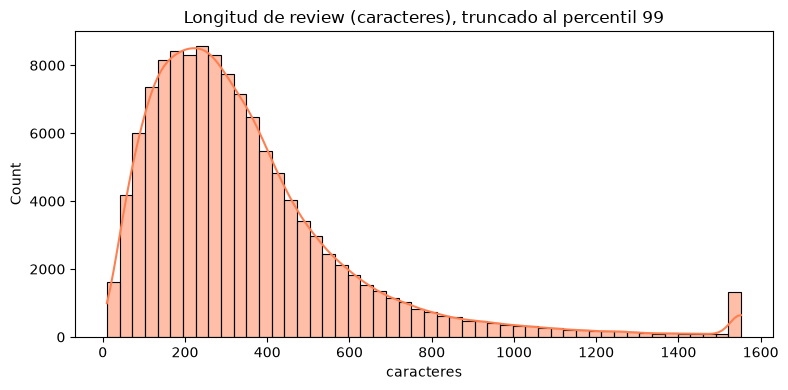

In [9]:
#Para todas las reseñas del sector

import matplotlib.pyplot as plt
import seaborn as sns

rl = df["review"].astype(str).str.len()
plt.figure(figsize=(8, 4))
sns.histplot(rl.clip(upper=rl.quantile(0.99)), bins=50, kde=True, color="coral")
plt.title("Longitud de review (caracteres), truncado al percentil 99")
plt.xlabel("caracteres")
plt.tight_layout()
plt.show()

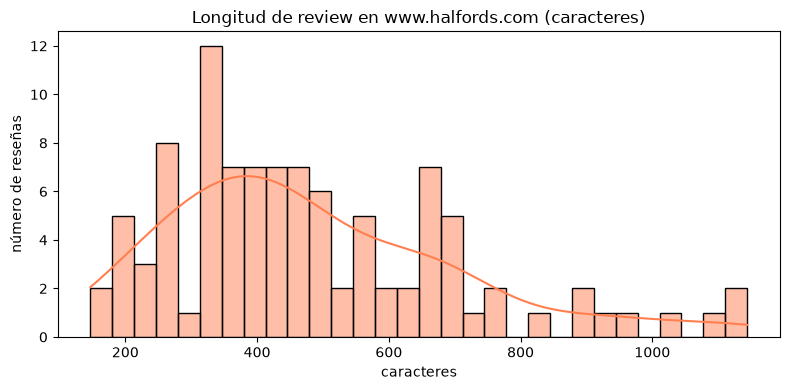

In [10]:
#Para las reseñas de la empresa objetivo

import matplotlib.pyplot as plt
import seaborn as sns

r1 = df_target["review"].astype(str).str.len()

plt.figure(figsize=(8, 4))
sns.histplot(r1.clip(upper=r1.quantile(0.99)), bins=30, kde=True, color="coral")
plt.title("Longitud de review en www.halfords.com (caracteres)")
plt.xlabel("caracteres")
plt.ylabel("número de reseñas")
plt.tight_layout()
plt.show()

In [11]:
# ver que tipos de caracteres tenemos para construir la funcion de limpieza: hastags, emojis, urls, menciones, saltos de linea, signos de puntuacion, numeros, etc

# Observación de patrones frecuentes en las reseñas de la empresa objetivo

text_series = df_target["review"].astype(str)

# Patrón aproximado para detectar emojis y símbolos gráficos frecuentes
emoji_pattern = (
    r"[\U0001F600-\U0001F64F"  # emoticonos
    r"\U0001F300-\U0001F5FF"   # símbolos y pictogramas
    r"\U0001F680-\U0001F6FF"   # transporte y mapas
    r"\U0001F1E0-\U0001F1FF"   # banderas
    r"\U00002700-\U000027BF"   # símbolos varios
    r"\U00002600-\U000026FF]"  # símbolos varios
)

char_patterns = {
    "reviews_con_url": text_series.str.contains(r"http\S+|www\.\S+", regex=True).sum(),
    "reviews_con_email": text_series.str.contains(r"\b[\w\.-]+@[\w\.-]+\.\w+\b", regex=True).sum(),
    "reviews_con_menciones": text_series.str.contains(r"@\w+", regex=True).sum(),
    "reviews_con_hashtags": text_series.str.contains(r"#\w+", regex=True).sum(),
    "reviews_con_emojis": text_series.str.contains(emoji_pattern, regex=True).sum(),
    "reviews_con_numeros": text_series.str.contains(r"\d+", regex=True).sum(),
    "reviews_con_saltos_linea": text_series.str.contains(r"\n", regex=True).sum(),
    "reviews_con_signos_puntuacion": text_series.str.contains(r"[^\w\s]", regex=True).sum(),
    "reviews_con_exclamacion": text_series.str.contains(r"!", regex=True).sum(),
    "reviews_con_interrogacion": text_series.str.contains(r"\?", regex=True).sum(),
    "reviews_con_comillas": text_series.str.contains(r"[\"']", regex=True).sum(),
    "reviews_con_guiones": text_series.str.contains(r"-|–|—", regex=True).sum(),
    "reviews_con_parentesis": text_series.str.contains(r"\(|\)", regex=True).sum(),
    "reviews_con_barras": text_series.str.contains(r"/|\\", regex=True).sum(),
    "reviews_con_simbolos_monetarios": text_series.str.contains(r"£|\$|€", regex=True).sum(),
    "reviews_con_mayusculas": text_series.str.contains(r"[A-Z]{2,}", regex=True).sum()
}

char_patterns_df = pd.DataFrame(
    char_patterns.items(),
    columns=["patron", "n_reviews"]
)

char_patterns_df["pct_reviews"] = (
    char_patterns_df["n_reviews"] / len(df_target) * 100
).round(2)

char_patterns_df


,patron,n_reviews,pct_reviews
0,reviews_con_url,0,0.0
1,reviews_con_email,0,0.0
2,reviews_con_menciones,0,0.0
3,reviews_con_hashtags,1,1.0
4,reviews_con_emojis,0,0.0
5,reviews_con_numeros,65,65.0
6,reviews_con_saltos_linea,0,0.0
7,reviews_con_signos_puntuacion,100,100.0
8,reviews_con_exclamacion,20,20.0
9,reviews_con_interrogacion,18,18.0


En esta sección se observa la estructura textual de las reseñas de `www.halfords.com`. La longitud de los textos y la presencia de elementos como números, signos de puntuación, saltos de línea o URLs ayudan a decidir qué limpieza aplicar antes del análisis de topics.

Para el modelo de sentimiento se mantendrá el texto lo más natural posible, ya que los modelos transformer suelen funcionar mejor con frases completas. En cambio, para el análisis de topics se aplicará una limpieza más intensa para reducir ruido y mejorar la extracción de palabras representativas.

## 5) Observamos que tipos de caracteres tenemos y Construimos la funcion de limpieza



A partir de la exploración anterior, se construye una función de limpieza textual orientada al análisis de topics. Esta función elimina elementos que pueden introducir ruido en la extracción de temas, como URLs, emails, menciones, hashtags, signos de puntuación, números y espacios duplicados.

Para el análisis de sentimiento se conservará una versión más natural del texto, ya que los modelos transformer suelen funcionar mejor con el texto original o ligeramente normalizado.

In [12]:
# Creamos una columna de texto completo combinando título y reseña.
# Esta versión se usará como texto original para sentimiento.

df_target["text_original"] = (
    df_target["title"].astype(str).fillna("") + ". " + df_target["review"].astype(str).fillna("")
)

df_competition["text_original"] = (
    df_competition["title"].astype(str).fillna("") + ". " + df_competition["review"].astype(str).fillna("")
)

df_sector["text_original"] = (
    df_sector["title"].astype(str).fillna("") + ". " + df_sector["review"].astype(str).fillna("")
)

df_target[["company", "title", "review", "text_original"]].head(3)

,company,title,review,text_original
77735,www.halfords.com,Windscreen wiper fitted in record time,Like an idiot I left the automatic windscreen ...,Windscreen wiper fitted in record time. Like a...
77736,www.halfords.com,Halfords Livingston going above and beyond…,I’m not one for leaving reviews but after my v...,Halfords Livingston going above and beyond… . ...
77737,www.halfords.com,I just wanted to name check Bradley at…,I just wanted to name check Bradley at your He...,I just wanted to name check Bradley at…. I jus...


In [13]:
import html

def clean_text_for_topics(text):
    """
    Limpieza de texto orientada al análisis de topics.
    
    La función elimina o normaliza elementos que pueden generar ruido
    en modelos basados en frecuencia de palabras, como TF-IDF + NMF.
    """
    
    # Convertir a string y decodificar entidades HTML
    text = str(text)
    text = html.unescape(text)
    
    # Normalizar apóstrofes y comillas raras
    text = text.replace("’", "'").replace("‘", "'").replace("“", '"').replace("”", '"')
    
    # Separar palabras pegadas por cambio de minúscula a mayúscula: visitingOrder -> visiting Order
    text = re.sub(r"([a-z])([A-Z])", r"\1 \2", text)
    
    # Pasar a minúsculas
    text = text.lower()
    
    # Eliminar URLs
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    
    # Eliminar emails
    text = re.sub(r"\b[\w\.-]+@[\w\.-]+\.\w+\b", " ", text)
    
    # Eliminar menciones
    text = re.sub(r"@\w+", " ", text)
    
    # Mantener la palabra del hashtag, pero quitar el símbolo #
    text = re.sub(r"#(\w+)", r"\1", text)
    
    # Convertir contracciones frecuentes
    text = re.sub(r"\bcan't\b", "cannot", text)
    text = re.sub(r"\bwon't\b", "will not", text)
    text = re.sub(r"n't\b", " not", text)
    text = re.sub(r"'re\b", " are", text)
    text = re.sub(r"'ve\b", " have", text)
    text = re.sub(r"'ll\b", " will", text)
    text = re.sub(r"'d\b", " would", text)
    text = re.sub(r"'m\b", " am", text)
    
    # Eliminar saltos de línea y tabulaciones
    text = re.sub(r"[\n\r\t]", " ", text)
    
    # Eliminar números
    text = re.sub(r"\d+", " ", text)
    
    # Eliminar signos de puntuación y símbolos, conservando letras y espacios
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    
    # Eliminar palabras de una sola letra, pero conservar palabras de 2 letras como "no"
    text = re.sub(r"\b[a-zA-Z]{1}\b", " ", text)
    
    # Normalizar espacios
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

In [14]:
# Aplicamos la limpieza a la empresa objetivo, a la competencia y al sector completo

df_target["text_clean"] = df_target["text_original"].apply(clean_text_for_topics)
df_competition["text_clean"] = df_competition["text_original"].apply(clean_text_for_topics)
df_sector["text_clean"] = df_sector["text_original"].apply(clean_text_for_topics)

df_target[["text_original", "text_clean"]].head(5)

,text_original,text_clean
77735,Windscreen wiper fitted in record time. Like a...,windscreen wiper fitted in record time like an...
77736,Halfords Livingston going above and beyond… . ...,halfords livingston going above and beyond am ...
77737,I just wanted to name check Bradley at…. I jus...,just wanted to name check bradley at just want...
77738,Just took my correro e bike to Halfords…. Just...,just took my correro bike to halfords just too...
77739,Brake light bulb fitting . Had a brake light b...,brake light bulb fitting had brake light bulb ...


In [15]:
# Comparación visual de texto original vs texto limpio

for i in df_target.sample(3, random_state=42).index:
    print("=" * 100)
    print("TEXTO ORIGINAL:")
    print(df_target.loc[i, "text_original"])
    print("\nTEXTO LIMPIO:")
    print(df_target.loc[i, "text_clean"])

TEXTO ORIGINAL:
This is going to become a legal matter . This is going to become a legal matter I have had non stop problems with the White City Halfords that lead to injury and when it’s this consistent it’s clearly incompetence or just blatant disregard I  come in today for a simple inner tuber replacement tell me why after riding for 10-15 mins my tire deflates and throws me off the bike and now I have whiplash I need this resolving I am beyond fuming get in touch now 

TEXTO LIMPIO:
this is going to become legal matter this is going to become legal matter have had non stop problems with the white city halfords that lead to injury and when it this consistent it clearly incompetence or just blatant disregard come in today for simple inner tuber replacement tell me why after riding for mins my tire deflates and throws me off the bike and now have whiplash need this resolving am beyond fuming get in touch now
TEXTO ORIGINAL:
 Wiper blade not the correct fitment.. Bought a rear wiper bl

In [16]:
# Longitud del texto antes y después de la limpieza

df_target["text_original_len"] = df_target["text_original"].str.len()
df_target["text_clean_len"] = df_target["text_clean"].str.len()

length_comparison = df_target[["text_original_len", "text_clean_len"]].describe()

length_comparison

,text_original_len,text_clean_len
count,100.000000,100.000000
mean,520.880000,490.150000
std,226.410251,210.562084
min,181.000000,173.000000
25%,367.250000,347.250000
50%,472.000000,441.500000
75%,667.250000,622.500000
max,1270.000000,1220.000000


In [17]:
# Comprobamos si la limpieza ha generado textos vacíos

empty_clean_texts = (df_target["text_clean"].str.len() == 0).sum()

print("Textos limpios vacíos en la empresa objetivo:", empty_clean_texts)

# Si hubiera textos vacíos, los eliminaríamos para el análisis de topics
df_target_topics = df_target[df_target["text_clean"].str.len() > 0].copy()
df_competition_topics = df_competition[df_competition["text_clean"].str.len() > 0].copy()
df_sector_topics = df_sector[df_sector["text_clean"].str.len() > 0].copy()

print("Reseñas de Halfords disponibles para topics:", df_target_topics.shape[0])
print("Reseñas de competencia disponibles para topics:", df_competition_topics.shape[0])
print("Reseñas del sector disponibles para topics:", df_sector_topics.shape[0])

Textos limpios vacíos en la empresa objetivo: 0
Reseñas de Halfords disponibles para topics: 100
Reseñas de competencia disponibles para topics: 5665
Reseñas del sector disponibles para topics: 5765


La función de limpieza reduce el ruido textual para el análisis de topics, eliminando elementos poco informativos como URLs, emails, números, puntuación y espacios duplicados. 

Se mantiene una diferencia metodológica entre el texto usado para sentimiento y el texto usado para topics: el sentimiento se calculará sobre `text_original`, mientras que los topics se extraerán a partir de `text_clean`.

Esta decisión permite aprovechar mejor cada técnica: los modelos de sentimiento necesitan contexto lingüístico natural, mientras que los modelos de topics basados en frecuencia funcionan mejor con textos normalizados.

## 6) Filtrado del sector de la compañía objetivo

Filtramos el dataset para quedarnos con el sector de la empresa objetivo, `Vehicles & Transportation`. A partir de este subconjunto separamos las reseñas de `www.halfords.com` y las reseñas del resto de empresas del sector, que se utilizarán como competencia.

Este filtrado permite comparar el comportamiento de la empresa objetivo frente a compañías del mismo ámbito de actividad.

In [18]:
# Filtramos por sector y separamos empresa objetivo y competencia

df_sector = df[df["category"] == CAT].copy()
df_target = df_sector[df_sector["company"] == TARGET].copy()
df_competition = df_sector[df_sector["company"] != TARGET].copy()

print("Sector objetivo:", CAT)
print("Empresa objetivo:", TARGET)
print("-" * 60)
print("Reseñas del sector:", df_sector.shape[0])
print("Empresas del sector:", df_sector["company"].nunique())
print("Reseñas de la empresa objetivo:", df_target.shape[0])
print("Reseñas de la competencia:", df_competition.shape[0])
print("Empresas competidoras:", df_competition["company"].nunique())

Sector objetivo: Vehicles & Transportation
Empresa objetivo: www.halfords.com
------------------------------------------------------------
Reseñas del sector: 5765
Empresas del sector: 60
Reseñas de la empresa objetivo: 100
Reseñas de la competencia: 5665
Empresas competidoras: 59


In [19]:
# Comprobamos que la empresa objetivo está en el fichero de empresas con 100 reseñas

target_emp100 = emp_100[emp_100["company"] == TARGET]

display(target_emp100)

if len(target_emp100) == 1:
    print("La empresa objetivo está correctamente incluida entre las empresas con 100 reseñas.")
else:
    print("Revisar: la empresa objetivo no aparece o aparece más de una vez.")

,category,company,n_reviews,median_stars,media_stars,std_stars
195,Vehicles & Transportation,www.halfords.com,100,3,3,1.421338


La empresa objetivo está correctamente incluida entre las empresas con 100 reseñas.


In [20]:
# Empresas del mismo sector con 100 reseñas

emp_100_sector = emp_100[emp_100["category"] == CAT].copy()

print("Empresas con 100 reseñas en el sector objetivo:", emp_100_sector.shape[0])

display(
    emp_100_sector
    .sort_values(["media_stars", "std_stars"], ascending=[False, True])
    .head(10)
)

Empresas con 100 reseñas en el sector objetivo: 45


,category,company,n_reviews,median_stars,media_stars,std_stars
141,Vehicles & Transportation,brompton.com,100,3,3,1.421338
147,Vehicles & Transportation,1stchoice.co.uk,100,3,3,1.421338
148,Vehicles & Transportation,etyres.co.uk,100,3,3,1.421338
149,Vehicles & Transportation,revive-uk.com,100,3,3,1.421338
150,Vehicles & Transportation,farmerautocare.com,100,3,3,1.421338
151,Vehicles & Transportation,fixauto.com,100,3,3,1.421338
152,Vehicles & Transportation,flixbus.co.uk,100,3,3,1.421338
153,Vehicles & Transportation,haynes.com,100,3,3,1.421338
154,Vehicles & Transportation,justpark.com,100,3,3,1.421338
155,Vehicles & Transportation,paulscycles.co.uk,100,3,3,1.421338


In [21]:
# Definimos una competencia comparable:
# empresas del mismo sector que también tienen 100 reseñas, excluyendo Halfords.

comparable_companies = (
    emp_100_sector[emp_100_sector["company"] != TARGET]["company"]
    .unique()
    .tolist()
)

df_competition_100 = df_sector[df_sector["company"].isin(comparable_companies)].copy()

print("Empresas competidoras comparables:", len(comparable_companies))
print("Reseñas de competidores comparables:", df_competition_100.shape[0])

Empresas competidoras comparables: 44
Reseñas de competidores comparables: 4400


In [22]:
# Demostramos que la comparación está equilibrada

reviews_by_company = (
    df_sector[df_sector["company"].isin([TARGET] + comparable_companies)]
    .groupby("company")
    .size()
    .reset_index(name="n_reviews")
    .sort_values("n_reviews", ascending=False)
)

display(reviews_by_company.head(10))

print("Mínimo de reseñas por empresa comparable:", reviews_by_company["n_reviews"].min())
print("Máximo de reseñas por empresa comparable:", reviews_by_company["n_reviews"].max())

,company,n_reviews
0,1stchoice.co.uk,100
1,brompton.com,100
2,etyres.co.uk,100
3,farmerautocare.com,100
4,fixauto.com,100
5,flixbus.co.uk,100
6,haynes.com,100
7,justpark.com,100
8,paulscycles.co.uk,100
9,pod-point.com,100


Mínimo de reseñas por empresa comparable: 100
Máximo de reseñas por empresa comparable: 100


,stars,n_reviews
0,1,20
1,2,20
2,3,20
3,4,20
4,5,20


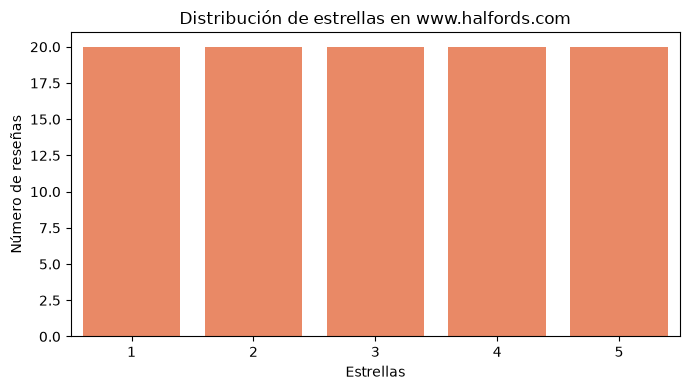

In [23]:
# Distribución de estrellas de la empresa objetivo.
# Las estrellas se muestran solo como descripción inicial del dataset.

stars_target = (
    df_target["stars"]
    .value_counts()
    .sort_index()
    .reset_index()
)

stars_target.columns = ["stars", "n_reviews"]

display(stars_target)

plt.figure(figsize=(7, 4))
sns.barplot(data=stars_target, x="stars", y="n_reviews", color="coral")
plt.title("Distribución de estrellas en www.halfords.com")
plt.xlabel("Estrellas")
plt.ylabel("Número de reseñas")
plt.tight_layout()
plt.show()

La empresa `www.halfords.com` tiene 100 reseñas distribuidas de forma perfectamente equilibrada entre las cinco puntuaciones de estrellas: 20 reseñas por cada valoración de 1 a 5. Esta distribución confirma el sesgo señalado en el enunciado de la actividad, por lo que la variable `stars` no se utilizará como medida de sentimiento.

Para la comparación competitiva se utilizarán empresas del mismo sector, `Vehicles & Transportation`. El sector contiene 5.765 reseñas y 60 empresas. Además, se identifica un subconjunto de 44 empresas competidoras comparables, todas ellas con 100 reseñas, lo que permite una comparación más equilibrada frente a `www.halfords.com`.

La distribución de estrellas se muestra únicamente como una descripción inicial del dataset. No se utilizará como medida de sentimiento, ya que el enunciado indica expresamente que el dataset está sesgado y que debe emplearse un modelo de sentimiento.

Por este motivo, el análisis de sentimiento posterior se basará en un modelo NLP aplicado al texto de las reseñas.

## 7) Sentimiento
Aplicamos la funcion de limpieza y el sentimiento


Aplicamos un modelo de sentimiento sobre el texto original de las reseñas. Para esta parte no se utiliza la columna `stars`, ya que el enunciado indica que el dataset está sesgado.

El modelo se aplicará a `www.halfords.com` y a las empresas competidoras comparables del mismo sector, para poder comparar la proporción de reseñas positivas, negativas y neutras.

In [24]:
# Preparamos el texto que se usará para el análisis de sentimiento.
# Usamos título + review para dar más contexto al modelo.

df_target["text_original"] = (
    df_target["title"].astype(str).fillna("") + ". " + df_target["review"].astype(str).fillna("")
)

df_competition_100["text_original"] = (
    df_competition_100["title"].astype(str).fillna("") + ". " + df_competition_100["review"].astype(str).fillna("")
)

print("Reseñas de Halfords para sentimiento:", df_target.shape[0])
print("Reseñas de competencia comparable para sentimiento:", df_competition_100.shape[0])

df_target[["company", "stars", "text_original"]].head(3)

Reseñas de Halfords para sentimiento: 100
Reseñas de competencia comparable para sentimiento: 4400


,company,stars,text_original
77735,www.halfords.com,5,Windscreen wiper fitted in record time. Like a...
77736,www.halfords.com,5,Halfords Livingston going above and beyond… . ...
77737,www.halfords.com,5,I just wanted to name check Bradley at…. I jus...


Inicialmente se planteó el uso de un modelo transformer de sentimiento. Sin embargo, para garantizar la reproducibilidad del análisis en el entorno local, se emplea VADER Sentiment, un modelo NLP basado en léxico y reglas diseñado para clasificar sentimiento en textos de opinión en inglés.

Esta elección cumple la restricción principal del ejercicio: el sentimiento se obtiene a partir del contenido textual de las reseñas y no de la variable `stars`, que solo se utiliza de forma descriptiva.

In [25]:
# Comprobamos si VADER está instalado en el entorno

try:
    from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
    
    sentiment_model = SentimentIntensityAnalyzer()
    print("VADER está instalado y el modelo se ha cargado correctamente.")
    
except ModuleNotFoundError:
    print("VADER no está instalado en este entorno.")

VADER está instalado y el modelo se ha cargado correctamente.


In [26]:
def get_vader_sentiment(text):
    """
    Aplica VADER Sentiment a un texto y devuelve:
    - sentiment_label: negative, neutral o positive
    - sentiment_score: compound score entre -1 y 1
    """
    
    scores = sentiment_model.polarity_scores(str(text))
    compound = scores["compound"]
    
    if compound >= 0.05:
        label = "positive"
    elif compound <= -0.05:
        label = "negative"
    else:
        label = "neutral"
    
    return label, compound

print("Función de sentimiento definida correctamente.")

Función de sentimiento definida correctamente.


In [27]:
# Probamos el modelo con algunas reseñas de Halfords antes de aplicarlo a todo el dataset

for text in df_target["text_original"].head(5):
    label, score = get_vader_sentiment(text)
    
    print("=" * 100)
    print(text[:500])
    print("\nSentimiento:", label)
    print("Score:", score)

Windscreen wiper fitted in record time. Like an idiot I left the automatic windscreen wiper on and in the frost it tried to wipe and tore off drivers side windscreen wiper rubber. Popped into Halfords at Wellingborough and Bradley was really helpful. Making sure I had the correct blade and fitting it in record time. Must remember to turn off automatic windscreen wipers.

Sentimiento: positive
Score: 0.5936
Halfords Livingston going above and beyond… . I’m not one for leaving reviews but after my visit to Halfords in Livingston and the service I received it feels like the right thing to do. Mikey in the Livingston branch went above and beyond of what would be described as general/good customer service. Not only did he help me find the correct bulb for my car, but he also took it out the car to fit it whilst I waited to pay because I had my two young children with me. He was very knowledgeable when 

Sentimiento: positive
Score: 0.8197
I just wanted to name check Bradley at…. I just want

In [28]:
# Aplicamos el modelo a Halfords

target_sentiments = df_target["text_original"].apply(get_vader_sentiment)

df_target["sentiment_label"] = target_sentiments.apply(lambda x: x[0])
df_target["sentiment_score"] = target_sentiments.apply(lambda x: x[1])

# Aplicamos el modelo a la competencia comparable

competition_sentiments = df_competition_100["text_original"].apply(get_vader_sentiment)

df_competition_100["sentiment_label"] = competition_sentiments.apply(lambda x: x[0])
df_competition_100["sentiment_score"] = competition_sentiments.apply(lambda x: x[1])

print("Sentimiento calculado para Halfords:", df_target["sentiment_label"].notna().sum())
print("Sentimiento calculado para competencia:", df_competition_100["sentiment_label"].notna().sum())

Sentimiento calculado para Halfords: 100
Sentimiento calculado para competencia: 4400


In [29]:
SENTIMENT_ORDER = ["negative", "neutral", "positive"]

def sentiment_summary(data, group_name):
    summary = (
        data["sentiment_label"]
        .value_counts()
        .reindex(SENTIMENT_ORDER, fill_value=0)
        .reset_index()
    )
    
    summary.columns = ["sentiment_label", "n_reviews"]
    summary["pct_reviews"] = (summary["n_reviews"] / summary["n_reviews"].sum() * 100).round(2)
    summary["group"] = group_name
    
    return summary


summary_target = sentiment_summary(df_target, "Halfords")
summary_competition = sentiment_summary(df_competition_100, "Competencia comparable")

sentiment_comparison = pd.concat(
    [summary_target, summary_competition],
    ignore_index=True
)

sentiment_comparison

,sentiment_label,n_reviews,pct_reviews,group
0,negative,34,34.00,Halfords
1,neutral,3,3.00,Halfords
2,positive,63,63.00,Halfords
3,negative,1653,37.57,Competencia comparable
4,neutral,201,4.57,Competencia comparable
5,positive,2546,57.86,Competencia comparable


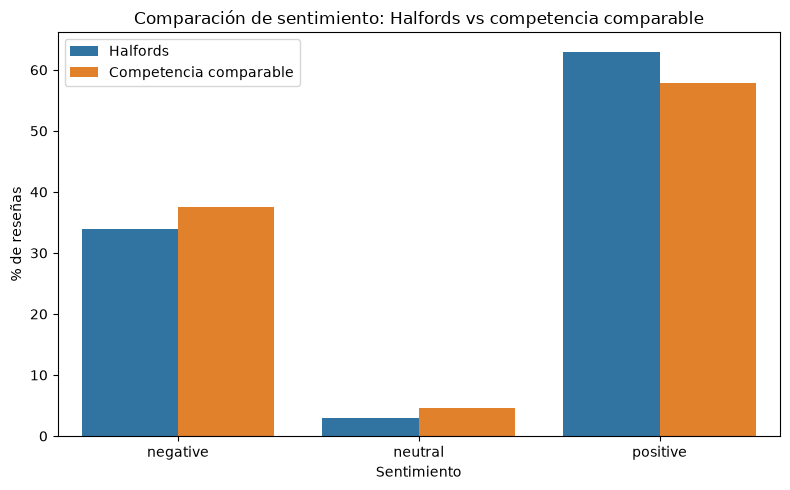

In [30]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=sentiment_comparison,
    x="sentiment_label",
    y="pct_reviews",
    hue="group",
    order=SENTIMENT_ORDER
)

plt.title("Comparación de sentimiento: Halfords vs competencia comparable")
plt.xlabel("Sentimiento")
plt.ylabel("% de reseñas")
plt.legend(title="")
plt.tight_layout()

plt.savefig("../outputs/sentimiento_halfords_vs_competencia.png", dpi=300, bbox_inches="tight")
plt.show()

In [31]:
sentiment_pivot = sentiment_comparison.pivot(
    index="sentiment_label",
    columns="group",
    values="pct_reviews"
).reindex(SENTIMENT_ORDER)

sentiment_pivot["diferencia_Halfords_vs_competencia"] = (
    sentiment_pivot["Halfords"] - sentiment_pivot["Competencia comparable"]
).round(2)

sentiment_pivot

group,Competencia comparable,Halfords,diferencia_Halfords_vs_competencia
sentiment_label,,,
negative,37.57,34.0,-3.57
neutral,4.57,3.0,-1.57
positive,57.86,63.0,5.14


El análisis de sentimiento se ha realizado a partir del contenido textual de las reseñas mediante VADER Sentiment, sin utilizar la variable `stars`.

Según el modelo, en `www.halfords.com` predomina el sentimiento positivo: el 63,00% de sus reseñas se clasifican como positivas, frente al 57,86% de la competencia comparable. Esto supone una diferencia favorable de +5,14 puntos porcentuales para Halfords.

En cuanto al sentimiento negativo, Halfords presenta un 34,00% de reseñas negativas, frente al 37,57% de la competencia comparable. Por tanto, la empresa tiene -3,57 puntos porcentuales menos de reseñas negativas que sus competidores comparables.

Las reseñas neutrales tienen un peso reducido en ambos grupos: 3,00% en Halfords y 4,57% en la competencia. En conjunto, los resultados sugieren que la percepción textual de los clientes de Halfords es ligeramente más favorable que la del promedio de empresas comparables del sector `Vehicles & Transportation`.

In [32]:
# Guardamos las tablas de sentimiento para usarlas en la presentación y conclusiones

sentiment_comparison.to_csv("../outputs/sentiment_comparison_halfords.csv", index=False)
sentiment_pivot.to_csv("../outputs/sentiment_pivot_halfords.csv")

print("Tablas de sentimiento guardadas correctamente.")

Tablas de sentimiento guardadas correctamente.


## 8) Topics



In [33]:
#%pip install --no-deps bertopic
#%pip install --upgrade numpy hdbscan umap-learn pandas scikit-learn tqdm plotly pyyaml
# Y reinicia kernel

# Opcional: instalación de BERTopic propuesta en la plantilla.
# No se ejecuta en este notebook para evitar problemas de instalación y reproducibilidad.

En esta sección se extraen los principales temas tratados en las reseñas de `www.halfords.com`.

La plantilla plantea la posibilidad de utilizar BERTopic, pero también incluye desde el inicio las librerías `TfidfVectorizer` y `NMF`. Por ello, en este notebook se utiliza TF-IDF + NMF como método de topic modeling, ya que permite identificar temas de forma estable, reproducible y adecuada para un conjunto de 100 reseñas.

El análisis se realiza sobre el texto limpio (`text_clean`), generado previamente en la función de limpieza.

In [34]:
# Comprobamos que tenemos disponible el texto limpio para extraer topics

print("¿Existe text_clean en df_target?", "text_clean" in df_target.columns)
print("¿Existe text_clean en df_competition_100?", "text_clean" in df_competition_100.columns)

print("Reseñas de Halfords:", df_target.shape[0])
print("Reseñas de competencia comparable:", df_competition_100.shape[0])

¿Existe text_clean en df_target? False
¿Existe text_clean en df_competition_100? False
Reseñas de Halfords: 100
Reseñas de competencia comparable: 4400


In [36]:
print("¿Existe clean_text_for_topics?", "clean_text_for_topics" in globals())

¿Existe clean_text_for_topics? True


In [37]:
# Recalculamos text_original y text_clean justo antes del análisis de topics.
# Esto evita perder columnas si df_target o df_competition_100 se han reconstruido después de la limpieza.

df_target["text_original"] = (
    df_target["title"].astype(str).fillna("") + ". " + df_target["review"].astype(str).fillna("")
)

df_competition_100["text_original"] = (
    df_competition_100["title"].astype(str).fillna("") + ". " + df_competition_100["review"].astype(str).fillna("")
)

df_target["text_clean"] = df_target["text_original"].apply(clean_text_for_topics)
df_competition_100["text_clean"] = df_competition_100["text_original"].apply(clean_text_for_topics)

print("¿Existe text_clean en df_target?", "text_clean" in df_target.columns)
print("¿Existe text_clean en df_competition_100?", "text_clean" in df_competition_100.columns)

print("Textos limpios vacíos en Halfords:", (df_target["text_clean"].str.len() == 0).sum())
print("Textos limpios vacíos en competencia:", (df_competition_100["text_clean"].str.len() == 0).sum())

¿Existe text_clean en df_target? True
¿Existe text_clean en df_competition_100? True
Textos limpios vacíos en Halfords: 0
Textos limpios vacíos en competencia: 0


In [38]:
# Preparamos los textos que se usarán para topic modeling

df_target_topics = df_target[df_target["text_clean"].str.len() > 0].copy()
df_competition_topics = df_competition_100[df_competition_100["text_clean"].str.len() > 0].copy()

print("Reseñas de Halfords disponibles para topics:", df_target_topics.shape[0])
print("Reseñas de competencia disponibles para topics:", df_competition_topics.shape[0])

df_target_topics[["company", "text_clean"]].head(3)

Reseñas de Halfords disponibles para topics: 100
Reseñas de competencia disponibles para topics: 4400


,company,text_clean
77735,www.halfords.com,windscreen wiper fitted in record time like an...
77736,www.halfords.com,halfords livingston going above and beyond am ...
77737,www.halfords.com,just wanted to name check bradley at just want...


In [39]:
# Vectorización TF-IDF para las reseñas de Halfords

vectorizer = TfidfVectorizer(
    max_df=0.90,          # elimina palabras demasiado frecuentes
    min_df=2,             # conserva palabras que aparecen al menos en 2 reseñas
    stop_words="english", # elimina stopwords en inglés
    ngram_range=(1, 2),   # palabras individuales y pares de palabras
    max_features=1000
)

tfidf_target = vectorizer.fit_transform(df_target_topics["text_clean"])

print("Matriz TF-IDF Halfords:", tfidf_target.shape)

Matriz TF-IDF Halfords: (100, 738)


In [42]:
# Parámetro de reproducibilidad
RANDOM_STATE = 42

print("RANDOM_STATE definido:", RANDOM_STATE)

RANDOM_STATE definido: 42


In [43]:
# Entrenamos el modelo NMF para extraer topics

nmf_model = NMF(
    n_components=N_TOPICS,
    random_state=RANDOM_STATE,
    init="nndsvda",
    max_iter=500
)

W_target = nmf_model.fit_transform(tfidf_target)
H_target = nmf_model.components_

print("Matriz documento-topic W:", W_target.shape)
print("Matriz topic-palabra H:", H_target.shape)

Matriz documento-topic W: (100, 6)
Matriz topic-palabra H: (6, 738)


In [44]:
# Extraemos las palabras más representativas de cada topic

feature_names = vectorizer.get_feature_names_out()

def get_top_words_per_topic(model, feature_names, top_words=12):
    topics = []
    
    for topic_idx, topic in enumerate(model.components_):
        top_indices = topic.argsort()[::-1][:top_words]
        top_terms = [feature_names[i] for i in top_indices]
        
        topics.append({
            "topic_id": topic_idx,
            "top_words": ", ".join(top_terms)
        })
    
    return pd.DataFrame(topics)

topics_words = get_top_words_per_topic(
    nmf_model,
    feature_names,
    top_words=TOP_WORDS
)

topics_words

,topic_id,top_words
0,0,"service, tyre, halfords, customer, chat, car, ..."
1,1,"bike, buy, bike halfords, bought, repair, bett..."
2,2,"battery, guarantee, told, warranty, car, order..."
3,3,"store, staff, helpful, visited, store today, t..."
4,4,"bulb, went, light, light bulb, brake light, br..."
5,5,"blade, wiper, windscreen, wiper blade, windscr..."


In [45]:
# Asignamos nombres interpretables a los topics según sus palabras principales

topic_names = {
    0: "Atención al cliente y servicio general",
    1: "Bicicletas, compra y reparaciones",
    2: "Baterías, garantía y pedidos",
    3: "Experiencia en tienda y personal",
    4: "Bombillas y luces del vehículo",
    5: "Limpiaparabrisas y escobillas"
}

topics_words["topic_name"] = topics_words["topic_id"].map(topic_names)

topics_words = topics_words[["topic_id", "topic_name", "top_words"]]

topics_words

,topic_id,topic_name,top_words
0,0,Atención al cliente y servicio general,"service, tyre, halfords, customer, chat, car, ..."
1,1,"Bicicletas, compra y reparaciones","bike, buy, bike halfords, bought, repair, bett..."
2,2,"Baterías, garantía y pedidos","battery, guarantee, told, warranty, car, order..."
3,3,Experiencia en tienda y personal,"store, staff, helpful, visited, store today, t..."
4,4,Bombillas y luces del vehículo,"bulb, went, light, light bulb, brake light, br..."
5,5,Limpiaparabrisas y escobillas,"blade, wiper, windscreen, wiper blade, windscr..."


In [46]:
# Asignamos a cada reseña el topic dominante según el mayor peso en W

df_target_topics["topic_id"] = W_target.argmax(axis=1)
df_target_topics["topic_score"] = W_target.max(axis=1)
df_target_topics["topic_name"] = df_target_topics["topic_id"].map(topic_names)

df_target_topics[["company", "sentiment_label", "topic_id", "topic_name", "topic_score", "text_original"]].head(10)

,company,sentiment_label,topic_id,topic_name,topic_score,text_original
77735,www.halfords.com,positive,5,Limpiaparabrisas y escobillas,0.564043,Windscreen wiper fitted in record time. Like a...
77736,www.halfords.com,positive,4,Bombillas y luces del vehículo,0.236944,Halfords Livingston going above and beyond… . ...
77737,www.halfords.com,positive,4,Bombillas y luces del vehículo,0.412444,I just wanted to name check Bradley at…. I jus...
77738,www.halfords.com,positive,1,"Bicicletas, compra y reparaciones",0.230394,Just took my correro e bike to Halfords…. Just...
77739,www.halfords.com,positive,4,Bombillas y luces del vehículo,0.612482,Brake light bulb fitting . Had a brake light b...
77740,www.halfords.com,positive,3,Experiencia en tienda y personal,0.078310,Sarah at Halfords Rugbywas so helpful &…. Sara...
77741,www.halfords.com,positive,4,Bombillas y luces del vehículo,0.158110,I went to Blanchardstown 3/1/25 at…. I went to...
77742,www.halfords.com,positive,4,Bombillas y luces del vehículo,0.373849,Great service. The driver's side headlight wen...
77743,www.halfords.com,positive,3,Experiencia en tienda y personal,0.217483,Kevin in Chesterfield 👍. Went into the Chester...
77744,www.halfords.com,positive,3,Experiencia en tienda y personal,0.357502,Halfords Store Catford SE London. Halfords Sto...


In [47]:
# Distribución de topics en las reseñas de Halfords

topic_distribution = (
    df_target_topics
    .groupby(["topic_id", "topic_name"])
    .size()
    .reset_index(name="n_reviews")
    .sort_values("n_reviews", ascending=False)
)

topic_distribution["pct_reviews"] = (
    topic_distribution["n_reviews"] / topic_distribution["n_reviews"].sum() * 100
).round(2)

topic_distribution

,topic_id,topic_name,n_reviews,pct_reviews
0,0,Atención al cliente y servicio general,29,29.0
3,3,Experiencia en tienda y personal,19,19.0
4,4,Bombillas y luces del vehículo,18,18.0
1,1,"Bicicletas, compra y reparaciones",15,15.0
2,2,"Baterías, garantía y pedidos",12,12.0
5,5,Limpiaparabrisas y escobillas,7,7.0


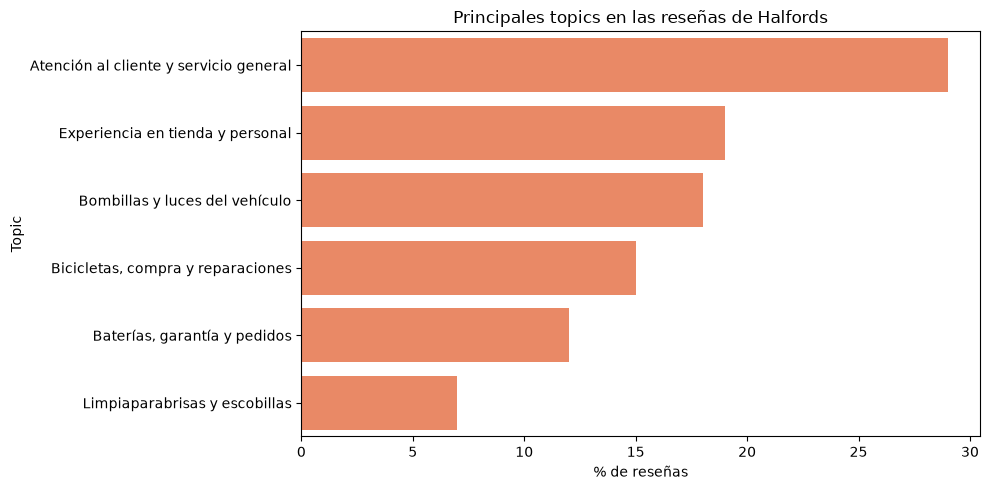

In [49]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=topic_distribution,
    x="pct_reviews",
    y="topic_name",
    color="coral"
)

plt.title("Principales topics en las reseñas de Halfords")
plt.xlabel("% de reseñas")
plt.ylabel("Topic")
plt.tight_layout()

plt.savefig("../outputs/topics_halfords.png", dpi=300, bbox_inches="tight")
plt.show()

Los topics extraídos muestran que las reseñas de `www.halfords.com` se concentran principalmente en aspectos relacionados con el servicio y la experiencia de cliente.

El tema más frecuente es **Atención al cliente y servicio general**, que representa el 29,00% de las reseñas. Le siguen **Experiencia en tienda y personal** con el 19,00% y **Bombillas y luces del vehículo** con el 18,00%.

También aparecen temas específicos vinculados a productos y servicios característicos de Halfords, como **Bicicletas, compra y reparaciones** (15,00%), **Baterías, garantía y pedidos** (12,00%) y **Limpiaparabrisas y escobillas** (7,00%).

Estos resultados indican que las reseñas no se limitan a valoraciones genéricas, reflejan puntos concretos de contacto con el cliente: atención recibida, servicio en tienda, instalación de componentes del vehículo, reparaciones y procesos postventa.

In [50]:
# Sentimiento predominante por topic en Halfords

sentiment_by_topic = (
    df_target_topics
    .groupby(["topic_id", "topic_name", "sentiment_label"])
    .size()
    .reset_index(name="n_reviews")
)

# Calculamos el porcentaje dentro de cada topic
sentiment_by_topic["pct_within_topic"] = (
    sentiment_by_topic["n_reviews"] /
    sentiment_by_topic.groupby("topic_id")["n_reviews"].transform("sum") *
    100
).round(2)

sentiment_by_topic = sentiment_by_topic.sort_values(
    ["topic_id", "sentiment_label"]
)

sentiment_by_topic

,topic_id,topic_name,sentiment_label,n_reviews,pct_within_topic
0,0,Atención al cliente y servicio general,negative,16,55.17
1,0,Atención al cliente y servicio general,neutral,1,3.45
2,0,Atención al cliente y servicio general,positive,12,41.38
3,1,"Bicicletas, compra y reparaciones",negative,5,33.33
4,1,"Bicicletas, compra y reparaciones",positive,10,66.67
5,2,"Baterías, garantía y pedidos",negative,6,50.00
6,2,"Baterías, garantía y pedidos",positive,6,50.00
7,3,Experiencia en tienda y personal,negative,2,10.53
8,3,Experiencia en tienda y personal,positive,17,89.47
9,4,Bombillas y luces del vehículo,negative,2,11.11


In [51]:
# Tabla resumen: sentimiento predominante por topic

topic_sentiment_summary = (
    sentiment_by_topic
    .sort_values(["topic_id", "n_reviews"], ascending=[True, False])
    .groupby(["topic_id", "topic_name"])
    .first()
    .reset_index()
)

topic_sentiment_summary = topic_sentiment_summary.rename(columns={
    "sentiment_label": "sentimiento_predominante",
    "n_reviews": "n_reviews_sentimiento_predominante",
    "pct_within_topic": "pct_sentimiento_predominante"
})

# Añadimos el total de reseñas por topic
topic_totals = (
    df_target_topics
    .groupby(["topic_id", "topic_name"])
    .size()
    .reset_index(name="total_reviews_topic")
)

topic_sentiment_summary = topic_sentiment_summary.merge(
    topic_totals,
    on=["topic_id", "topic_name"],
    how="left"
)

topic_sentiment_summary = topic_sentiment_summary[
    [
        "topic_id",
        "topic_name",
        "total_reviews_topic",
        "sentimiento_predominante",
        "n_reviews_sentimiento_predominante",
        "pct_sentimiento_predominante"
    ]
]

topic_sentiment_summary

,topic_id,topic_name,total_reviews_topic,sentimiento_predominante,n_reviews_sentimiento_predominante,pct_sentimiento_predominante
0,0,Atención al cliente y servicio general,29,negative,16,55.17
1,1,"Bicicletas, compra y reparaciones",15,positive,10,66.67
2,2,"Baterías, garantía y pedidos",12,negative,6,50.00
3,3,Experiencia en tienda y personal,19,positive,17,89.47
4,4,Bombillas y luces del vehículo,18,positive,15,83.33
5,5,Limpiaparabrisas y escobillas,7,negative,3,42.86


In [ ]:
# Creamos una tabla pivot para ver el porcentaje de cada sentimiento dentro de cada topic. Esta tabla no fuerza como negativo lo que realmente es mixto etc

topic_sentiment_pivot = (
    sentiment_by_topic
    .pivot_table(
        index=["topic_id", "topic_name"],
        columns="sentiment_label",
        values="pct_within_topic",
        fill_value=0
    )
    .reset_index()
)

# Aseguramos que existan todas las columnas
for col in SENTIMENT_ORDER:
    if col not in topic_sentiment_pivot.columns:
        topic_sentiment_pivot[col] = 0

topic_sentiment_pivot = topic_sentiment_pivot[
    ["topic_id", "topic_name", "negative", "neutral", "positive"]
]

# Añadimos total de reseñas por topic
topic_sentiment_pivot = topic_sentiment_pivot.merge(
    topic_totals,
    on=["topic_id", "topic_name"],
    how="left"
)

# Función para interpretar el sentimiento del topic
def classify_topic_sentiment(row):
    neg = row["negative"]
    neu = row["neutral"]
    pos = row["positive"]
    
    if abs(pos - neg) <= 5:
        return "mixto"
    elif pos > neg and pos >= neu:
        return "positive"
    elif neg > pos and neg >= neu:
        return "negative"
    else:
        return "neutral"

topic_sentiment_pivot["sentimiento_topic"] = topic_sentiment_pivot.apply(
    classify_topic_sentiment,
    axis=1
)

topic_sentiment_pivot = topic_sentiment_pivot.sort_values(
    "total_reviews_topic",
    ascending=False
)

topic_sentiment_pivot

,topic_id,topic_name,negative,neutral,positive,total_reviews_topic,sentimiento_topic
0,0,Atención al cliente y servicio general,55.17,3.45,41.38,29,negative
3,3,Experiencia en tienda y personal,10.53,0.00,89.47,19,positive
4,4,Bombillas y luces del vehículo,11.11,5.56,83.33,18,positive
1,1,"Bicicletas, compra y reparaciones",33.33,0.00,66.67,15,positive
2,2,"Baterías, garantía y pedidos",50.00,0.00,50.00,12,mixto
5,5,Limpiaparabrisas y escobillas,42.86,14.29,42.86,7,mixto


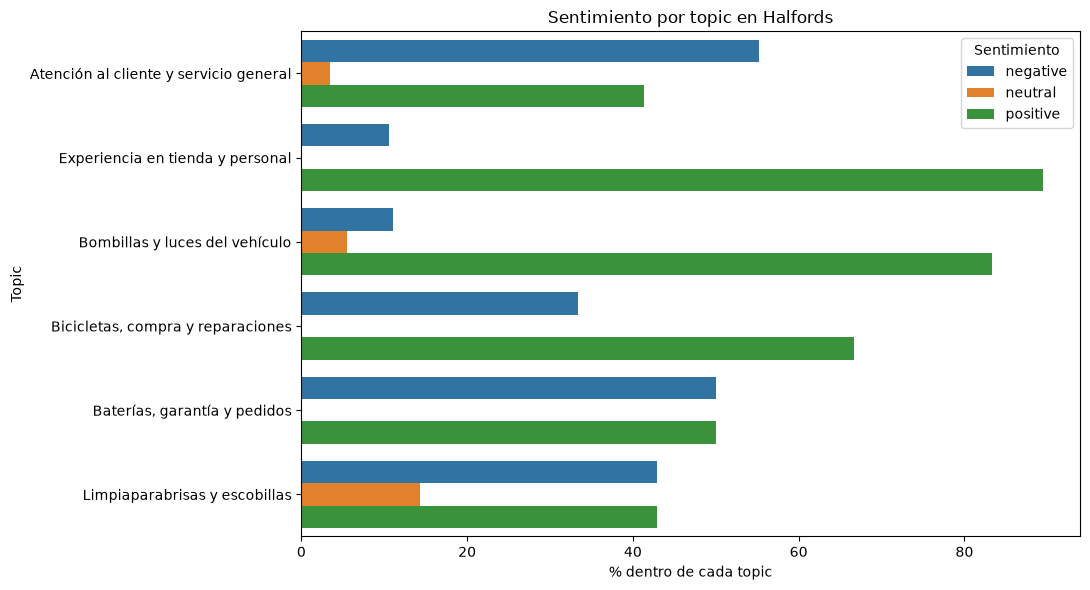

In [54]:
# Preparamos datos en formato largo para visualizar sentimiento por topic

topic_sentiment_long = topic_sentiment_pivot.melt(
    id_vars=["topic_id", "topic_name", "total_reviews_topic", "sentimiento_topic"],
    value_vars=["negative", "neutral", "positive"],
    var_name="sentiment_label",
    value_name="pct_within_topic"
)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=topic_sentiment_long,
    x="pct_within_topic",
    y="topic_name",
    hue="sentiment_label",
    hue_order=SENTIMENT_ORDER
)

plt.title("Sentimiento por topic en Halfords")
plt.xlabel("% dentro de cada topic")
plt.ylabel("Topic")
plt.legend(title="Sentimiento")
plt.tight_layout()

plt.savefig("../outputs/sentimiento_por_topic_halfords.png", dpi=300, bbox_inches="tight")
plt.show()

El análisis combinado de sentimiento y topics muestra diferencias relevantes entre los temas tratados en las reseñas de `www.halfords.com`.

El topic **Atención al cliente y servicio general** es el más frecuente y presenta predominio de sentimiento negativo: el 55,17% de sus reseñas se clasifican como negativas. Esto lo convierte en una de las principales áreas de mejora.

En cambio, los topics **Experiencia en tienda y personal** y **Bombillas y luces del vehículo** muestran un comportamiento claramente positivo, con un 89,47% y un 83,33% de reseñas positivas respectivamente. Estos temas pueden considerarse fortalezas de la compañía.

El topic **Bicicletas, compra y reparaciones** también presenta predominio positivo, con un 66,67% de reseñas positivas, aunque mantiene un 33,33% de reseñas negativas.

Por último, **Baterías, garantía y pedidos** y **Limpiaparabrisas y escobillas** presentan un sentimiento mixto, con equilibrio entre reseñas positivas y negativas. Estos temas requieren una revisión cualitativa más detallada para identificar qué elementos generan satisfacción y cuáles provocan insatisfacción.

In [56]:
# Aplicamos el mismo vectorizador y modelo NMF a la competencia comparable.
# Así podemos comparar la competencia usando los mismos topics definidos para Halfords.

tfidf_competition = vectorizer.transform(df_competition_topics["text_clean"])

W_competition = nmf_model.transform(tfidf_competition)

df_competition_topics["topic_id"] = W_competition.argmax(axis=1)
df_competition_topics["topic_score"] = W_competition.max(axis=1)
df_competition_topics["topic_name"] = df_competition_topics["topic_id"].map(topic_names)

print("Matriz TF-IDF competencia:", tfidf_competition.shape)
print("Matriz documento-topic competencia:", W_competition.shape)

df_competition_topics[["company", "sentiment_label", "topic_id", "topic_name", "topic_score", "text_original"]].head(10)

Matriz TF-IDF competencia: (4400, 738)
Matriz documento-topic competencia: (4400, 6)


,company,sentiment_label,topic_id,topic_name,topic_score,text_original
75999,www.autowindscreens.co.uk,positive,5,Limpiaparabrisas y escobillas,0.159322,Professional and friendly staff. Although it t...
76000,www.autowindscreens.co.uk,positive,4,Bombillas y luces del vehículo,0.134407,Great customer care and service. Good afternoo...
76001,www.autowindscreens.co.uk,positive,5,Limpiaparabrisas y escobillas,0.154471,Fast and Efficient Service. Within a couple of...
76002,www.autowindscreens.co.uk,positive,4,Bombillas y luces del vehículo,0.138042,Brilliant chap called Tom fitted my…. Brillian...
76003,www.autowindscreens.co.uk,positive,3,Experiencia en tienda y personal,0.064766,Perfect service of window replacement . Very p...
76004,www.autowindscreens.co.uk,positive,0,Atención al cliente y servicio general,0.049486,auto windscreens fantastic. The whole thing fr...
76005,www.autowindscreens.co.uk,positive,4,Bombillas y luces del vehículo,0.090516,"Excellent service . Excellent service , can’t..."
76006,www.autowindscreens.co.uk,positive,5,Limpiaparabrisas y escobillas,0.087376,Fast Windscreen Repair Service on Isle of Wigh...
76007,www.autowindscreens.co.uk,positive,5,Limpiaparabrisas y escobillas,0.147205,Super fast windscreen repair service. Booked t...
76008,www.autowindscreens.co.uk,positive,5,Limpiaparabrisas y escobillas,0.112681,"Professional and polite . They were polite, of..."


In [57]:
# Distribución de topics: Halfords vs competencia comparable

topic_distribution_target = (
    df_target_topics
    .groupby(["topic_id", "topic_name"])
    .size()
    .reset_index(name="n_reviews")
)

topic_distribution_target["pct_reviews"] = (
    topic_distribution_target["n_reviews"] / topic_distribution_target["n_reviews"].sum() * 100
).round(2)

topic_distribution_target["group"] = "Halfords"


topic_distribution_competition = (
    df_competition_topics
    .groupby(["topic_id", "topic_name"])
    .size()
    .reset_index(name="n_reviews")
)

topic_distribution_competition["pct_reviews"] = (
    topic_distribution_competition["n_reviews"] / topic_distribution_competition["n_reviews"].sum() * 100
).round(2)

topic_distribution_competition["group"] = "Competencia comparable"


topic_distribution_comparison = pd.concat(
    [topic_distribution_target, topic_distribution_competition],
    ignore_index=True
)

topic_distribution_comparison.sort_values(["topic_id", "group"])

,topic_id,topic_name,n_reviews,pct_reviews,group
6,0,Atención al cliente y servicio general,1911,43.43,Competencia comparable
0,0,Atención al cliente y servicio general,29,29.00,Halfords
7,1,"Bicicletas, compra y reparaciones",772,17.55,Competencia comparable
1,1,"Bicicletas, compra y reparaciones",15,15.00,Halfords
8,2,"Baterías, garantía y pedidos",205,4.66,Competencia comparable
2,2,"Baterías, garantía y pedidos",12,12.00,Halfords
9,3,Experiencia en tienda y personal,348,7.91,Competencia comparable
3,3,Experiencia en tienda y personal,19,19.00,Halfords
10,4,Bombillas y luces del vehículo,709,16.11,Competencia comparable
4,4,Bombillas y luces del vehículo,18,18.00,Halfords


En Halfords pesan más los temas de experiencia en tienda, personal, baterías/garantías/pedidos y bombillas/luces. En la competencia, el tema más dominante es atención al cliente y servicio general, con un 43,43%.

In [58]:
topic_comparison_pivot = topic_distribution_comparison.pivot(
    index="topic_name",
    columns="group",
    values="pct_reviews"
).reset_index()

topic_comparison_pivot["diferencia_Halfords_vs_competencia"] = (
    topic_comparison_pivot["Halfords"] - topic_comparison_pivot["Competencia comparable"]
).round(2)

topic_comparison_pivot = topic_comparison_pivot.sort_values(
    "diferencia_Halfords_vs_competencia",
    ascending=False
)

topic_comparison_pivot

group,topic_name,Competencia comparable,Halfords,diferencia_Halfords_vs_competencia
4,Experiencia en tienda y personal,7.91,19.0,11.09
1,"Baterías, garantía y pedidos",4.66,12.0,7.34
3,Bombillas y luces del vehículo,16.11,18.0,1.89
2,"Bicicletas, compra y reparaciones",17.55,15.0,-2.55
5,Limpiaparabrisas y escobillas,10.34,7.0,-3.34
0,Atención al cliente y servicio general,43.43,29.0,-14.43


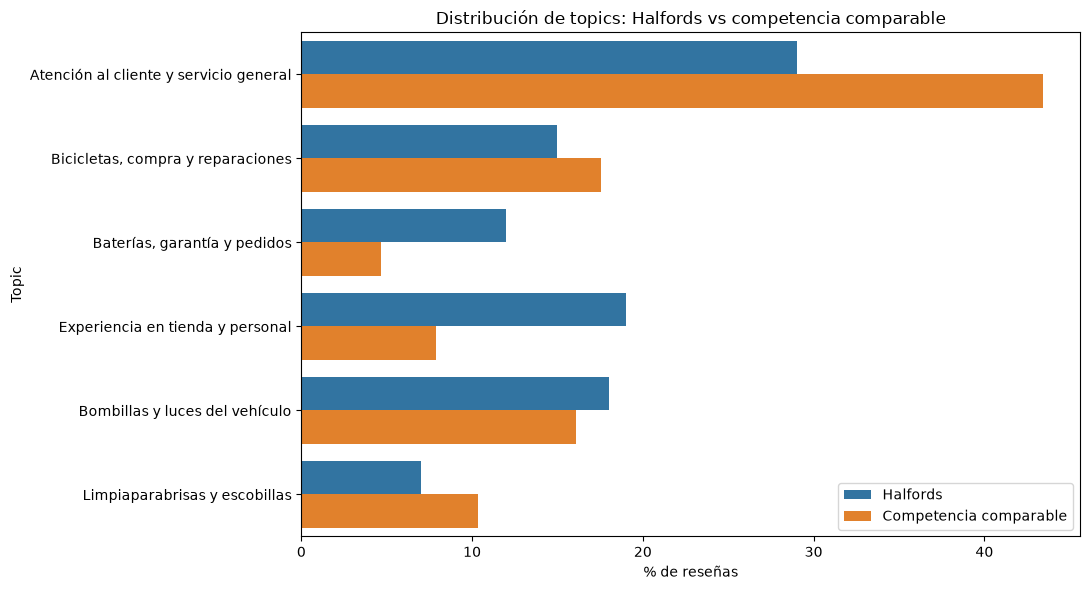

In [59]:
plt.figure(figsize=(11, 6))

sns.barplot(
    data=topic_distribution_comparison,
    x="pct_reviews",
    y="topic_name",
    hue="group"
)

plt.title("Distribución de topics: Halfords vs competencia comparable")
plt.xlabel("% de reseñas")
plt.ylabel("Topic")
plt.legend(title="")
plt.tight_layout()

plt.savefig("../outputs/topics_halfords_vs_competencia.png", dpi=300, bbox_inches="tight")
plt.show()

La comparación de topics muestra diferencias relevantes entre `www.halfords.com` y la competencia comparable.

Halfords presenta una mayor concentración relativa de reseñas sobre **Experiencia en tienda y personal** (+11,09 puntos porcentuales frente a la competencia), **Baterías, garantía y pedidos** (+7,34 puntos) y, en menor medida, **Bombillas y luces del vehículo** (+1,89 puntos). Esto sugiere que la experiencia presencial, la atención del personal y determinados servicios técnicos tienen un peso especialmente relevante en la percepción de sus clientes.

En cambio, la competencia comparable concentra una proporción mayor de reseñas en **Atención al cliente y servicio general** (+14,43 puntos frente a Halfords), además de una presencia algo superior en **Limpiaparabrisas y escobillas** y **Bicicletas, compra y reparaciones**.

Estos resultados permiten contextualizar los temas de Halfords dentro del sector: la compañía destaca especialmente por la experiencia en tienda y servicios concretos de mantenimiento del vehículo, mientras que el servicio general sigue siendo un tema crítico por su peso y por el sentimiento negativo observado previamente.

In [60]:
# Sentimiento por topic en la competencia comparable

sentiment_by_topic_competition = (
    df_competition_topics
    .groupby(["topic_id", "topic_name", "sentiment_label"])
    .size()
    .reset_index(name="n_reviews")
)

sentiment_by_topic_competition["pct_within_topic"] = (
    sentiment_by_topic_competition["n_reviews"] /
    sentiment_by_topic_competition.groupby("topic_id")["n_reviews"].transform("sum") *
    100
).round(2)

sentiment_by_topic_competition = sentiment_by_topic_competition.sort_values(
    ["topic_id", "sentiment_label"]
)

sentiment_by_topic_competition

,topic_id,topic_name,sentiment_label,n_reviews,pct_within_topic
0,0,Atención al cliente y servicio general,negative,868,45.42
1,0,Atención al cliente y servicio general,neutral,82,4.29
2,0,Atención al cliente y servicio general,positive,961,50.29
3,1,"Bicicletas, compra y reparaciones",negative,268,34.72
4,1,"Bicicletas, compra y reparaciones",neutral,35,4.53
5,1,"Bicicletas, compra y reparaciones",positive,469,60.75
6,2,"Baterías, garantía y pedidos",negative,89,43.41
7,2,"Baterías, garantía y pedidos",neutral,17,8.29
8,2,"Baterías, garantía y pedidos",positive,99,48.29
9,3,Experiencia en tienda y personal,negative,81,23.28


In [61]:
# Preparamos tabla de sentimiento por topic para Halfords

halfords_topic_sent = (
    sentiment_by_topic
    .pivot_table(
        index=["topic_id", "topic_name"],
        columns="sentiment_label",
        values="pct_within_topic",
        fill_value=0
    )
    .reset_index()
)

for col in SENTIMENT_ORDER:
    if col not in halfords_topic_sent.columns:
        halfords_topic_sent[col] = 0

halfords_topic_sent = halfords_topic_sent[
    ["topic_id", "topic_name", "negative", "neutral", "positive"]
]

halfords_topic_sent = halfords_topic_sent.rename(columns={
    "negative": "negative_halfords",
    "neutral": "neutral_halfords",
    "positive": "positive_halfords"
})


# Preparamos tabla de sentimiento por topic para competencia

competition_topic_sent = (
    sentiment_by_topic_competition
    .pivot_table(
        index=["topic_id", "topic_name"],
        columns="sentiment_label",
        values="pct_within_topic",
        fill_value=0
    )
    .reset_index()
)

for col in SENTIMENT_ORDER:
    if col not in competition_topic_sent.columns:
        competition_topic_sent[col] = 0

competition_topic_sent = competition_topic_sent[
    ["topic_id", "topic_name", "negative", "neutral", "positive"]
]

competition_topic_sent = competition_topic_sent.rename(columns={
    "negative": "negative_competencia",
    "neutral": "neutral_competencia",
    "positive": "positive_competencia"
})


# Unimos ambas tablas

topic_sentiment_comparison = halfords_topic_sent.merge(
    competition_topic_sent,
    on=["topic_id", "topic_name"],
    how="left"
)

topic_sentiment_comparison["dif_positive_halfords_vs_competencia"] = (
    topic_sentiment_comparison["positive_halfords"] -
    topic_sentiment_comparison["positive_competencia"]
).round(2)

topic_sentiment_comparison["dif_negative_halfords_vs_competencia"] = (
    topic_sentiment_comparison["negative_halfords"] -
    topic_sentiment_comparison["negative_competencia"]
).round(2)

topic_sentiment_comparison = topic_sentiment_comparison.sort_values(
    "dif_positive_halfords_vs_competencia",
    ascending=False
)

topic_sentiment_comparison

sentiment_label,topic_id,topic_name,negative_halfords,neutral_halfords,positive_halfords,negative_competencia,neutral_competencia,positive_competencia,dif_positive_halfords_vs_competencia,dif_negative_halfords_vs_competencia
3,3,Experiencia en tienda y personal,10.53,0.00,89.47,23.28,3.45,73.28,16.19,-12.75
4,4,Bombillas y luces del vehículo,11.11,5.56,83.33,25.95,3.10,70.94,12.39,-14.84
1,1,"Bicicletas, compra y reparaciones",33.33,0.00,66.67,34.72,4.53,60.75,5.92,-1.39
2,2,"Baterías, garantía y pedidos",50.00,0.00,50.00,43.41,8.29,48.29,1.71,6.59
0,0,Atención al cliente y servicio general,55.17,3.45,41.38,45.42,4.29,50.29,-8.91,9.75
5,5,Limpiaparabrisas y escobillas,42.86,14.29,42.86,35.82,7.25,56.92,-14.06,7.04


Halfords sale claramente mejor que la competencia en:

| Topic                             | Diferencia positiva | Diferencia negativa | Interpretación                           |
| --------------------------------- | ------------------: | ------------------: | ---------------------------------------- |
| Experiencia en tienda y personal  |           +16,19 pp |           -12,75 pp | Fortaleza clara                          |
| Bombillas y luces del vehículo    |           +12,39 pp |           -14,84 pp | Fortaleza clara                          |
| Bicicletas, compra y reparaciones |            +5,92 pp |            -1,39 pp | Mejor que competencia, aunque con margen |

Halfords sale peor que la competencia en:

| Topic                                  | Diferencia positiva | Diferencia negativa | Interpretación                              |
| -------------------------------------- | ------------------: | ------------------: | ------------------------------------------- |
| Atención al cliente y servicio general |            -8,91 pp |            +9,75 pp | Área de mejora prioritaria                  |
| Limpiaparabrisas y escobillas          |           -14,06 pp |            +7,04 pp | Área de mejora                              |
| Baterías, garantía y pedidos           |            +1,71 pp |            +6,59 pp | Tema mixto: genera satisfacción y problemas |


In [62]:
def classify_business_area(row):
    """
    Clasifica cada topic según su comparación con la competencia.
    """
    dif_pos = row["dif_positive_halfords_vs_competencia"]
    dif_neg = row["dif_negative_halfords_vs_competencia"]
    
    if dif_pos >= 5 and dif_neg <= 0:
        return "Fortaleza frente a competencia"
    elif dif_pos <= -5 and dif_neg >= 5:
        return "Área de mejora prioritaria"
    elif dif_neg >= 5:
        return "Área de mejora"
    elif dif_pos >= 5:
        return "Ventaja moderada"
    else:
        return "Situación similar a competencia"


topic_sentiment_comparison["lectura_negocio"] = topic_sentiment_comparison.apply(
    classify_business_area,
    axis=1
)

topic_sentiment_comparison[
    [
        "topic_name",
        "positive_halfords",
        "positive_competencia",
        "negative_halfords",
        "negative_competencia",
        "dif_positive_halfords_vs_competencia",
        "dif_negative_halfords_vs_competencia",
        "lectura_negocio"
    ]
]

sentiment_label,topic_name,positive_halfords,positive_competencia,negative_halfords,negative_competencia,dif_positive_halfords_vs_competencia,dif_negative_halfords_vs_competencia,lectura_negocio
3,Experiencia en tienda y personal,89.47,73.28,10.53,23.28,16.19,-12.75,Fortaleza frente a competencia
4,Bombillas y luces del vehículo,83.33,70.94,11.11,25.95,12.39,-14.84,Fortaleza frente a competencia
1,"Bicicletas, compra y reparaciones",66.67,60.75,33.33,34.72,5.92,-1.39,Fortaleza frente a competencia
2,"Baterías, garantía y pedidos",50.00,48.29,50.00,43.41,1.71,6.59,Área de mejora
0,Atención al cliente y servicio general,41.38,50.29,55.17,45.42,-8.91,9.75,Área de mejora prioritaria
5,Limpiaparabrisas y escobillas,42.86,56.92,42.86,35.82,-14.06,7.04,Área de mejora prioritaria


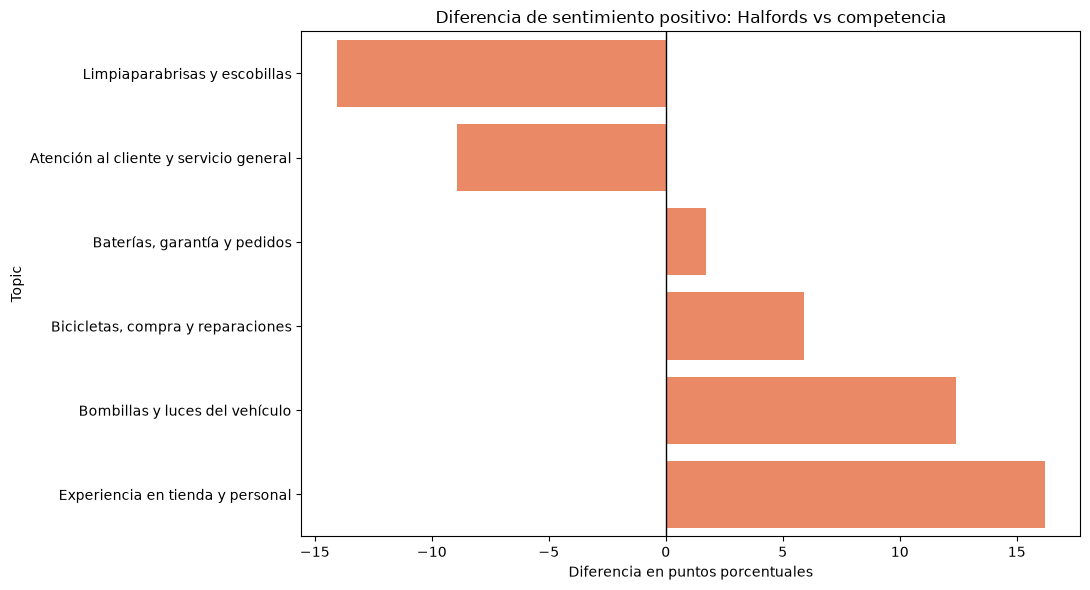

In [64]:
# Guardamos el gráfico

plt.figure(figsize=(11, 6))

plot_data = topic_sentiment_comparison.sort_values(
    "dif_positive_halfords_vs_competencia",
    ascending=True
)

sns.barplot(
    data=plot_data,
    x="dif_positive_halfords_vs_competencia",
    y="topic_name",
    color="coral"
)

plt.axvline(0, color="black", linewidth=1)
plt.title("Diferencia de sentimiento positivo: Halfords vs competencia")
plt.xlabel("Diferencia en puntos porcentuales")
plt.ylabel("Topic")
plt.tight_layout()

plt.savefig("../outputs/diferencia_sentimiento_positivo_topics.png", dpi=300, bbox_inches="tight")
plt.show()

In [65]:
# Guardamos tablas clave del análisis de topics

topics_words.to_csv("../outputs/topics_words_halfords.csv", index=False)
topic_distribution.to_csv("../outputs/topic_distribution_halfords.csv", index=False)
topic_sentiment_pivot.to_csv("../outputs/topic_sentiment_halfords.csv", index=False)
topic_distribution_comparison.to_csv("../outputs/topic_distribution_halfords_vs_competencia.csv", index=False)
topic_sentiment_comparison.to_csv("../outputs/topic_sentiment_halfords_vs_competencia.csv", index=False)

print("Tablas de topics guardadas correctamente.")

Tablas de topics guardadas correctamente.


El análisis de sentimiento por topic permite identificar fortalezas y áreas de mejora frente a la competencia.

Halfords obtiene mejores resultados que la competencia en **Experiencia en tienda y personal**, con +16,19 puntos porcentuales de sentimiento positivo y -12,75 puntos de sentimiento negativo. También destaca en **Bombillas y luces del vehículo**, donde supera a la competencia en +12,39 puntos de sentimiento positivo y presenta -14,84 puntos menos de sentimiento negativo. Estos dos temas pueden considerarse fortalezas claras de la compañía.

En **Bicicletas, compra y reparaciones**, Halfords también se sitúa por encima de la competencia, aunque con una ventaja más moderada: +5,92 puntos de sentimiento positivo y -1,39 puntos de sentimiento negativo.

Por el contrario, las principales áreas de mejora se concentran en **Atención al cliente y servicio general** y **Limpiaparabrisas y escobillas**. En atención al cliente, Halfords tiene -8,91 puntos menos de sentimiento positivo y +9,75 puntos más de sentimiento negativo que la competencia. En limpiaparabrisas y escobillas, la diferencia negativa es todavía mayor en sentimiento positivo: -14,06 puntos frente a la competencia.

El topic **Baterías, garantía y pedidos** presenta una situación mixta: Halfords tiene una proporción positiva similar a la competencia, pero también acumula más sentimiento negativo, por lo que debe revisarse como un área de mejora operativa y postventa.

# 9) Visualizaciones

En esta sección se agrupan visualizaciones finales que ayudan a comunicar los resultados principales del análisis. 

La plantilla propone el uso de `wordcloud`. En este notebook se intentará generar una nube de palabras a partir del texto limpio de las reseñas de `www.halfords.com`. Si la librería no está disponible, se utilizará una alternativa basada en frecuencia de términos para no depender de instalaciones adicionales.

In [35]:
#%pip install wordcloud

In [66]:
# Comprobamos si wordcloud está disponible

try:
    from wordcloud import WordCloud
    WORDCLOUD_AVAILABLE = True
    print("WordCloud está instalado.")
except ModuleNotFoundError:
    WORDCLOUD_AVAILABLE = False
    print("WordCloud no está instalado. Se usará una alternativa con frecuencias de palabras.")

WordCloud está instalado.


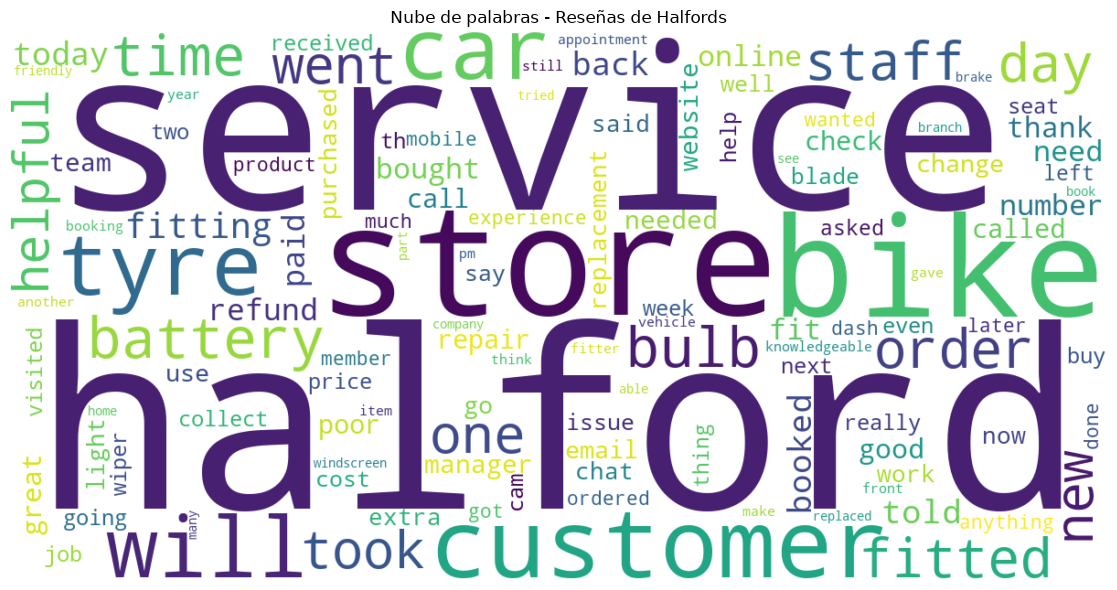

In [68]:
# Nube de palabras de las reseñas de Halfords

from wordcloud import WordCloud

text_for_wordcloud = " ".join(df_target_topics["text_clean"].dropna().astype(str))

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    max_words=120,
    collocations=False,
    random_state=RANDOM_STATE
).generate(text_for_wordcloud)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Nube de palabras - Reseñas de Halfords")
plt.tight_layout()

plt.savefig("../outputs/wordcloud_halfords.png", dpi=300, bbox_inches="tight")
plt.show()

La nube de palabras resume visualmente los términos más frecuentes en las reseñas limpias de `www.halfords.com`. Los términos destacados refuerzan los resultados del análisis de topics: aparecen palabras relacionadas con el servicio, la tienda, el personal, bicicletas, baterías, bombillas, limpiaparabrisas, pedidos y atención al cliente.

Esta visualización no sustituye al modelo de topics, pero ayuda a comunicar de forma rápida los conceptos más repetidos en las reseñas.

## 10) Conclusiones y áreas de mejora

En esta sección se resumen los principales resultados del análisis de sentimiento, topics y comparación con la competencia. El objetivo es transformar los resultados analíticos en conclusiones útiles para Customer Experience.

In [72]:
# Resumen global de sentimiento Halfords vs competencia

global_sentiment_summary = pd.DataFrame({
    "métrica": [
        "Sentimiento positivo Halfords",
        "Sentimiento positivo competencia",
        "Diferencia positiva Halfords vs competencia",
        "Sentimiento negativo Halfords",
        "Sentimiento negativo competencia",
        "Diferencia negativa Halfords vs competencia"
    ],
    "valor": [
        sentiment_pivot.loc["positive", "Halfords"],
        sentiment_pivot.loc["positive", "Competencia comparable"],
        sentiment_pivot.loc["positive", "diferencia_Halfords_vs_competencia"],
        sentiment_pivot.loc["negative", "Halfords"],
        sentiment_pivot.loc["negative", "Competencia comparable"],
        sentiment_pivot.loc["negative", "diferencia_Halfords_vs_competencia"]
    ]
})

global_sentiment_summary

,métrica,valor
0,Sentimiento positivo Halfords,63.00
1,Sentimiento positivo competencia,57.86
2,Diferencia positiva Halfords vs competencia,5.14
3,Sentimiento negativo Halfords,34.00
4,Sentimiento negativo competencia,37.57
5,Diferencia negativa Halfords vs competencia,-3.57


In [73]:
# Clasificación final de topics en fortalezas y áreas de mejora

def classify_business_area(row):
    dif_pos = row["dif_positive_halfords_vs_competencia"]
    dif_neg = row["dif_negative_halfords_vs_competencia"]
    
    if dif_pos >= 5 and dif_neg <= 0:
        return "Fortaleza frente a competencia"
    elif dif_pos <= -5 and dif_neg >= 5:
        return "Área de mejora prioritaria"
    elif dif_neg >= 5:
        return "Área de mejora"
    elif dif_pos >= 5:
        return "Ventaja moderada"
    else:
        return "Situación similar a competencia"


topic_sentiment_comparison["lectura_negocio"] = topic_sentiment_comparison.apply(
    classify_business_area,
    axis=1
)

acciones_recomendadas = {
    "Experiencia en tienda y personal": "Mantener y reforzar la atención presencial, identificando buenas prácticas del personal mejor valorado.",
    "Bombillas y luces del vehículo": "Consolidar este servicio como fortaleza, cuidando disponibilidad, rapidez de instalación y comunicación en tienda.",
    "Bicicletas, compra y reparaciones": "Revisar los casos negativos para mejorar consistencia en reparaciones, tiempos y expectativas del cliente.",
    "Baterías, garantía y pedidos": "Analizar incidencias de garantía, pedidos y comunicación postventa para reducir experiencias negativas.",
    "Atención al cliente y servicio general": "Priorizar la mejora del soporte, tiempos de respuesta, resolución de incidencias y comunicación con el cliente.",
    "Limpiaparabrisas y escobillas": "Revisar procesos de recomendación, ajuste e instalación para reducir errores o experiencias inconsistentes."
}

topic_sentiment_comparison["accion_recomendada"] = (
    topic_sentiment_comparison["topic_name"].map(acciones_recomendadas)
)

final_business_table = topic_sentiment_comparison[
    [
        "topic_name",
        "positive_halfords",
        "positive_competencia",
        "negative_halfords",
        "negative_competencia",
        "dif_positive_halfords_vs_competencia",
        "dif_negative_halfords_vs_competencia",
        "lectura_negocio",
        "accion_recomendada"
    ]
].copy()

final_business_table

final_business_table.to_csv("../outputs/conclusiones_areas_mejora_halfords.csv", index=False)

print("Tabla final de conclusiones guardada correctamente.")

Tabla final de conclusiones guardada correctamente.


El análisis de reseñas de `www.halfords.com` muestra una percepción global ligeramente más favorable que la de la competencia comparable del sector `Vehicles & Transportation`.

A nivel global, Halfords alcanza un **63,00% de reseñas positivas**, frente al **57,86%** de la competencia comparable. Esto supone una diferencia favorable de **+5,14 puntos porcentuales**. Además, presenta un **34,00% de reseñas negativas**, frente al **37,57%** de la competencia, lo que implica **-3,57 puntos porcentuales** menos de sentimiento negativo.

El análisis de topics identifica seis temas principales en las reseñas de Halfords: atención al cliente y servicio general, bicicletas y reparaciones, baterías y garantías, experiencia en tienda, bombillas y luces del vehículo, y limpiaparabrisas.

Las principales fortalezas de Halfords se concentran en **Experiencia en tienda y personal** y **Bombillas y luces del vehículo**. En el primer caso, Halfords supera a la competencia en **+16,19 puntos porcentuales** de sentimiento positivo y tiene **-12,75 puntos** menos de sentimiento negativo. En el segundo caso, supera a la competencia en **+12,39 puntos** de sentimiento positivo y presenta **-14,84 puntos** menos de sentimiento negativo. Estos resultados sugieren que la atención presencial y determinados servicios técnicos son puntos fuertes de la compañía.

También se observa una ventaja moderada en **Bicicletas, compra y reparaciones**, donde Halfords obtiene **+5,92 puntos** más de sentimiento positivo que la competencia.

Las principales áreas de mejora se concentran en **Atención al cliente y servicio general** y **Limpiaparabrisas y escobillas**. En atención al cliente, Halfords presenta **-8,91 puntos** menos de sentimiento positivo y **+9,75 puntos** más de sentimiento negativo que la competencia. Esto lo convierte en la prioridad principal desde el punto de vista de Customer Experience. En limpiaparabrisas y escobillas también se observa una posición desfavorable, con **-14,06 puntos** menos de sentimiento positivo y **+7,04 puntos** más de sentimiento negativo.

El topic **Baterías, garantía y pedidos** presenta una situación mixta. Aunque la proporción de sentimiento positivo es similar a la competencia, Halfords acumula más sentimiento negativo, por lo que conviene revisar procesos vinculados a garantías, pedidos, comunicación y resolución postventa.

En conjunto, el análisis sugiere que Halfords cuenta con fortalezas claras en la experiencia presencial y servicios concretos en tienda, pero debe priorizar la mejora del servicio general, la comunicación con el cliente y la gestión de incidencias postventa.

In [74]:
# Guardamos datasets procesados con sentimiento y topics

df_target_topics.to_csv(
    "../data/processed/halfords_reviews_sentiment_topics.csv",
    index=False
)

df_competition_topics.to_csv(
    "../data/processed/competencia_reviews_sentiment_topics.csv",
    index=False
)

print("Datasets procesados guardados correctamente.")
print("Halfords:", df_target_topics.shape)
print("Competencia:", df_competition_topics.shape)

Datasets procesados guardados correctamente.
Halfords: (100, 14)
Competencia: (4400, 14)


In [75]:
from pathlib import Path

outputs_path = Path("../outputs")
processed_path = Path("../data/processed")

print("Archivos en outputs:")
for file in sorted(outputs_path.glob("*")):
    print("-", file.name)

print("\nArchivos en data/processed:")
for file in sorted(processed_path.glob("*")):
    print("-", file.name)

Archivos en outputs:
- conclusiones_areas_mejora_halfords.csv
- diferencia_sentimiento_positivo_topics.png
- sentiment_comparison_halfords.csv
- sentiment_pivot_halfords.csv
- sentimiento_halfords_vs_competencia.png
- sentimiento_por_topic_halfords.png
- topic_distribution_halfords.csv
- topic_distribution_halfords_vs_competencia.csv
- topic_sentiment_halfords.csv
- topic_sentiment_halfords_vs_competencia.csv
- topics_halfords.png
- topics_halfords_vs_competencia.png
- topics_words_halfords.csv
- wordcloud_halfords.png

Archivos en data/processed:
- competencia_reviews_sentiment_topics.csv
- halfords_reviews_sentiment_topics.csv


Los archivos finales se organizan. Los CSV procesados se guardan en `data/processed/`, mientras que las imágenes y gráficos se conservan en `outputs/`. Esta separación facilita la reutilización de tablas para análisis posteriores y de gráficos para la presentación final.

In [77]:
from pathlib import Path
import shutil

outputs_path = Path("../outputs")
processed_path = Path("../data/processed")

processed_path.mkdir(parents=True, exist_ok=True)

# Mover CSV desde outputs a data/processed
for csv_file in outputs_path.glob("*.csv"):
    destination = processed_path / csv_file.name
    
    if destination.exists():
        destination.unlink()
    
    shutil.move(str(csv_file), str(destination))

print("CSV movidos de outputs a data/processed correctamente.")

print("\nArchivos en outputs:")
for file in sorted(outputs_path.glob("*")):
    print("-", file.name)

print("\nArchivos en data/processed:")
for file in sorted(processed_path.glob("*")):
    print("-", file.name)

CSV movidos de outputs a data/processed correctamente.

Archivos en outputs:
- diferencia_sentimiento_positivo_topics.png
- sentimiento_halfords_vs_competencia.png
- sentimiento_por_topic_halfords.png
- topics_halfords.png
- topics_halfords_vs_competencia.png
- wordcloud_halfords.png

Archivos en data/processed:
- competencia_reviews_sentiment_topics.csv
- conclusiones_areas_mejora_halfords.csv
- halfords_reviews_sentiment_topics.csv
- sentiment_comparison_halfords.csv
- sentiment_pivot_halfords.csv
- topic_distribution_halfords.csv
- topic_distribution_halfords_vs_competencia.csv
- topic_sentiment_halfords.csv
- topic_sentiment_halfords_vs_competencia.csv
- topics_words_halfords.csv
